# MapleFreight Logistics — Delivery Delay Prediction & Slack Alerts
**AML 3303 · Assessment 1**

## IMPORT FILES

In [ ]:
import os, warnings, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import requests
from dotenv import load_dotenv
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score, roc_auc_score,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
                             precision_recall_curve)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
DATA_PATH = "maplefreight_delivery_delay_dataset.csv"

## Data understanding

In [ ]:
raw = pd.read_csv(DATA_PATH)
print("Shape:", raw.shape)
display(raw.head())
display(raw.dtypes.to_frame("dtype").T)

Shape: (6035, 23)


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
0,SHP-103848,Mississauga ON,Edmonton AB,NorthStar Carriers,Standard,General Freight,Bronze,1,376.0,257.1,...,55.0,5.1,6.1,Fog,37.2,0.291,1,146.39,7.55,0
1,SHP-102827,Montreal QC,Winnipeg MB,PrairieLine,Standard,General Freight,Silver,12,159.8,734.1,...,69.0,5.3,4.2,Snow,77.4,0.236,0,155.07,1.17,1
2,SHP-105254,Toronto ON,Hamilton ON,QuebecExpress,Standard,Fragile,Silver,9,423.0,680.8,...,-13.0,1.4,2.8,Rain,36.5,0.344,0,163.44,6.47,0
3,SHP-102719,Montreal QC,Hamilton ON,MapleFreight Fleet,Standard,General Freight,Silver,1,494.1,1292.2,...,-20.0,4.0,14.8,Fog,51.2,0.491,2,NaN,8.03,0
4,SHP-105198,Mississauga ON,Sudbury ON,MapleFreight Fleet,Standard,Refrigerated,Bronze,9,843.5,3327.1,...,28.0,2.9,1.6,Clear,82.7,0.423,1,263.22,13.49,0


,shipment_id,origin_city,destination_city,carrier,service_level,goods_type,customer_priority_tier,shipment_month,distance_km,weight_kg,...,pickup_delay_minutes,driver_experience_years,vehicle_age_years,weather_condition,traffic_index,route_congestion_score,prior_late_deliveries_30d,fuel_cost_cad,actual_transit_hours,delivered_late
dtype,str,str,str,str,str,str,str,int64,float64,float64,...,float64,float64,float64,str,float64,float64,int64,float64,float64,int64


In [ ]:
missing = raw.isna().sum()
print("Missing values per column:")
print(missing[missing > 0].to_frame("n_missing").assign(pct=lambda d: (d.n_missing / len(raw) * 100).round(1)))
print("\nFully duplicated rows:", raw.duplicated().sum())
print("Duplicated shipment_id:", raw.shipment_id.duplicated().sum())
print("\nTarget balance:")
print(raw.delivered_late.value_counts(normalize=True).round(3))

Missing values per column:
                         n_missing  pct
driver_experience_years        210  3.5
weather_condition              150  2.5
traffic_index                  121  2.0
fuel_cost_cad                  240  4.0

Fully duplicated rows: 32
Duplicated shipment_id: 35

Target balance:
delivered_late
0    0.794
1    0.206
Name: proportion, dtype: float64


In [ ]:
print("Categorical value counts (note the inconsistent service_level spellings):")
for c in ["service_level", "weather_condition", "carrier", "goods_type", "customer_priority_tier"]:
    print(f"\n{c}:", raw[c].value_counts(dropna=False).to_dict())

print("\nWeight distribution (unit-error check):")
print(pd.cut(raw.weight_kg, [0, 100, 1000, 5000, 20000, 1e7]).value_counts().sort_index())
display(raw.weight_kg.nlargest(8).to_frame())

Categorical value counts (note the inconsistent service_level spellings):

service_level: {'Standard': 3219, 'Express': 1442, 'Economy': 1254, 'standard': 74, 'express': 27, 'economy': 19}

weather_condition: {'Clear': 2976, 'Rain': 1332, 'Snow': 869, 'Fog': 423, 'Storm': 285, nan: 150}

carrier: {'MapleFreight Fleet': 2391, 'NorthStar Carriers': 1164, 'PrairieLine': 932, 'QuebecExpress': 924, 'Contract Owner-Op': 624}

goods_type: {'General Freight': 2974, 'Refrigerated': 924, 'Fragile': 895, 'Bulk': 744, 'Hazardous': 498}

customer_priority_tier: {'Silver': 2775, 'Bronze': 2092, 'Gold': 1168}

Weight distribution (unit-error check):
weight_kg
(0.0, 100.0]               57
(100.0, 1000.0]          3636
(1000.0, 5000.0]         2301
(5000.0, 20000.0]           1
(20000.0, 10000000.0]      40
Name: count, dtype: int64


,weight_kg
2323,2999300.0
846,1593600.0
1525,1554700.0
3284,1408300.0
4761,1389500.0
696,1332200.0
4028,1246100.0
4876,1238200.0


## Data preprocessing (cleaning)
Cleaning steps, each justified by the checks above:

1. **Duplicates** – drop exact duplicate rows, then keep the first record for any `shipment_id` that still repeats (a shipment must be unique).
2. **Inconsistent spelling** – normalise `service_level` (`standard` / `Standard`).
3. **Unit error** – weights above 20,000 kg are impossible for these shipments and are exactly 1000× too large, so they were recorded in grams. Divide by 1000.
4. **Missing values** – `weather_condition` becomes an explicit `Unknown` category; numeric gaps (`driver_experience_years`, `traffic_index`, `fuel_cost_cad`) are imputed with the **training-set median inside the model pipeline** (with a missing-indicator), so no information from the test set leaks in.

In [ ]:
df = raw.copy()
n0 = len(df)
df = df.drop_duplicates()
n1 = len(df)
df = df.drop_duplicates(subset="shipment_id", keep="first")
print(f"Rows: {n0} -> {n1} after exact duplicates -> {len(df)} after unique shipment_id")

df["service_level"] = df.service_level.str.strip().str.title()

unit_fix = df.weight_kg > 20000
print("Weights converted from grams to kg:", unit_fix.sum())
df.loc[unit_fix, "weight_kg"] = df.loc[unit_fix, "weight_kg"] / 1000

df["weather_condition"] = df.weather_condition.fillna("Unknown")

print("\nservice_level now:", df.service_level.value_counts().to_dict())
print("weight_kg after fix:"); display(df.weight_kg.describe().round(1).to_frame().T)

Rows: 6035 -> 6003 after exact duplicates -> 6000 after unique shipment_id
Weights converted from grams to kg: 40

service_level now: {'Standard': 3275, 'Express': 1460, 'Economy': 1265}
weight_kg after fix:


,count,mean,std,min,25%,50%,75%,max
weight_kg,6000.0,953.9,618.4,30.0,494.6,823.4,1274.4,5044.0


## Exploratory data analysis

Overall late rate: 20.6%


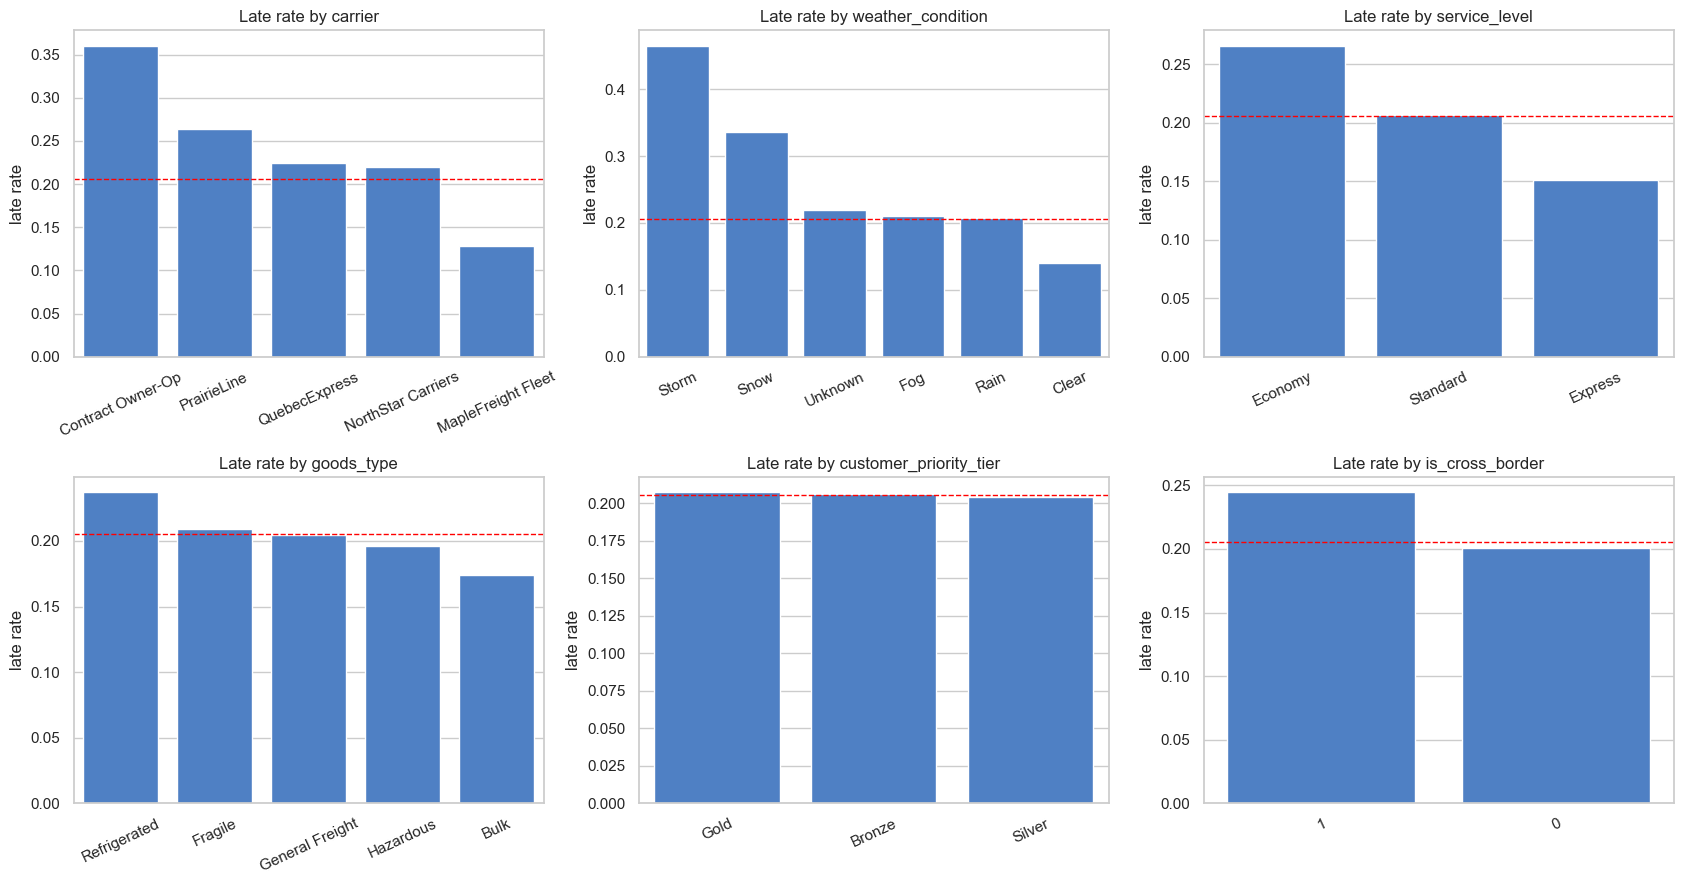

In [ ]:
overall = df.delivered_late.mean()
print(f"Overall late rate: {overall:.1%}")

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.ravel(), ["carrier", "weather_condition", "service_level",
                                  "goods_type", "customer_priority_tier", "is_cross_border"]):
    rate = df.groupby(col).delivered_late.mean().sort_values(ascending=False)
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color="#3b7dd8")
    ax.axhline(overall, color="red", ls="--", lw=1)
    ax.set_title(f"Late rate by {col}"); ax.set_ylabel("late rate"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

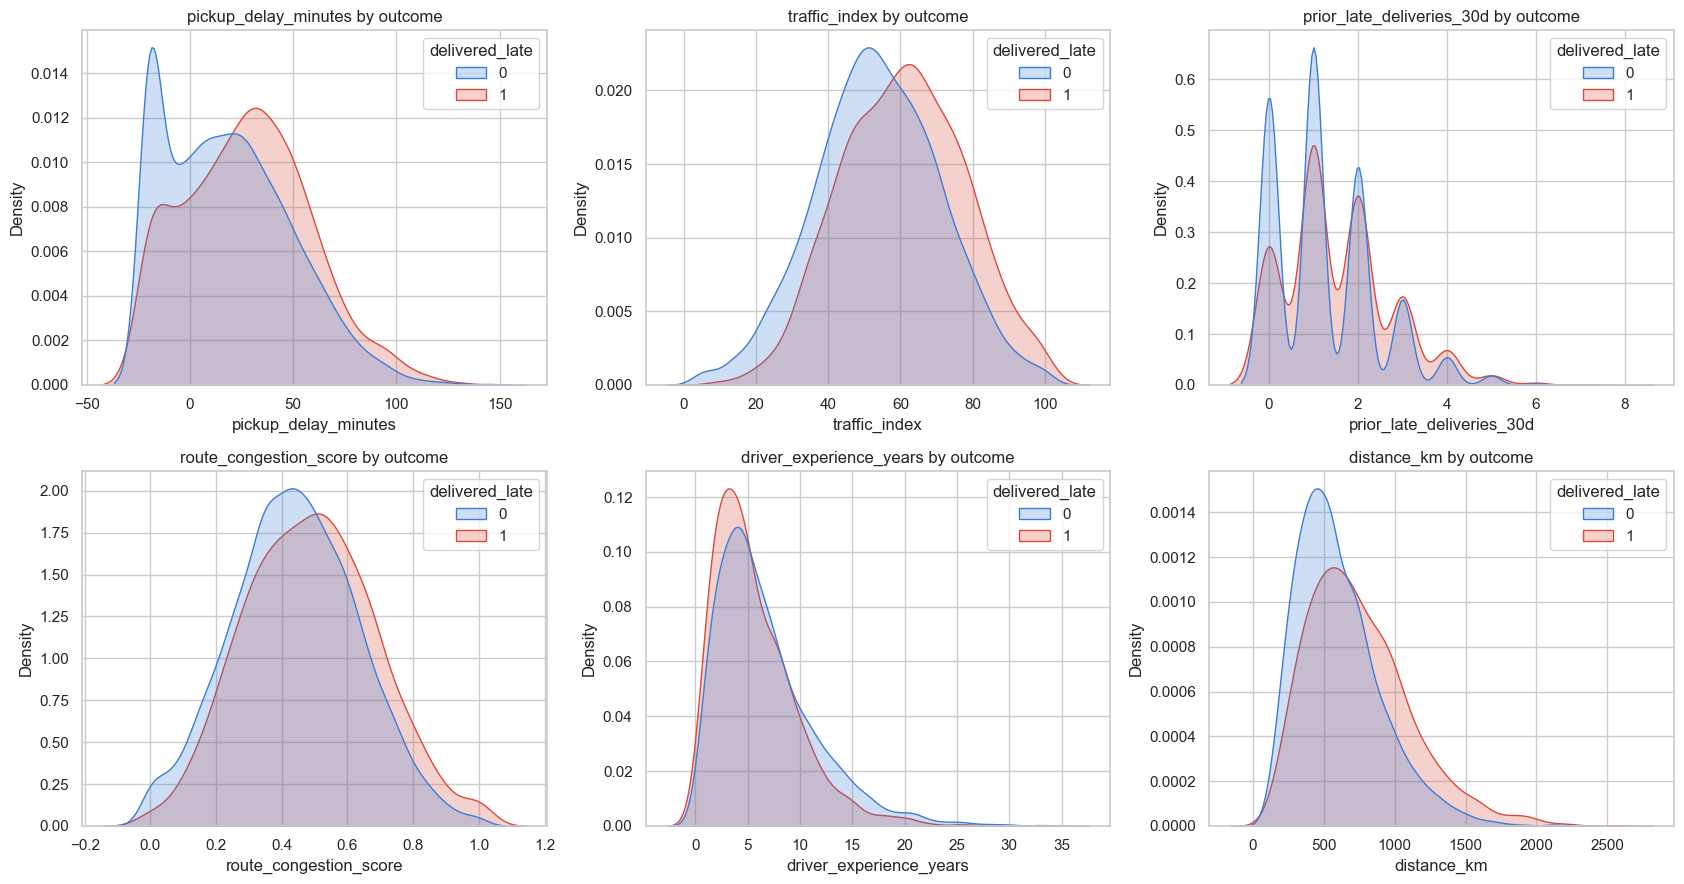

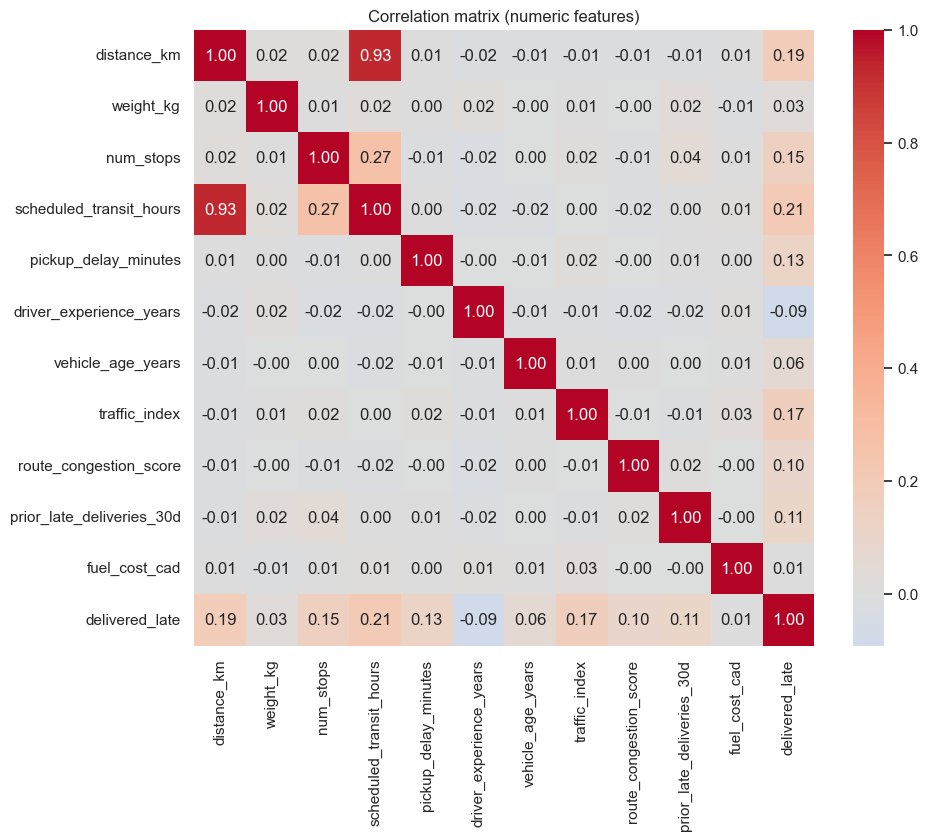

scheduled_transit_hours      0.210
distance_km                  0.185
traffic_index                0.166
num_stops                    0.155
pickup_delay_minutes         0.125
prior_late_deliveries_30d    0.107
route_congestion_score       0.100
vehicle_age_years            0.063
weight_kg                    0.028
fuel_cost_cad                0.008
driver_experience_years     -0.092
Name: delivered_late, dtype: float64


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, col in zip(axes.ravel(), ["pickup_delay_minutes", "traffic_index", "prior_late_deliveries_30d",
                                  "route_congestion_score", "driver_experience_years", "distance_km"]):
    sns.kdeplot(data=df, x=col, hue="delivered_late", common_norm=False, fill=True, ax=ax, palette=["#3b7dd8", "#d84a3b"])
    ax.set_title(f"{col} by outcome")
plt.tight_layout(); plt.show()

num_cols = ["distance_km", "weight_kg", "num_stops", "scheduled_transit_hours", "pickup_delay_minutes",
            "driver_experience_years", "vehicle_age_years", "traffic_index", "route_congestion_score",
            "prior_late_deliveries_30d", "fuel_cost_cad", "delivered_late"]
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric features)"); plt.show()
print(df[num_cols].corr()["delivered_late"].drop("delivered_late").sort_values(ascending=False).round(3))

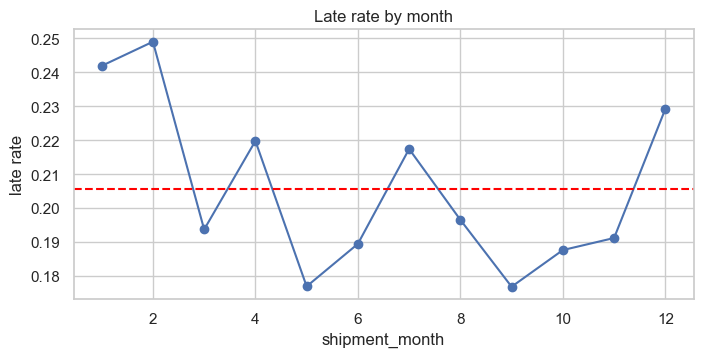

In [ ]:
monthly = df.groupby("shipment_month").delivered_late.mean()
plt.figure(figsize=(8, 3.5)); monthly.plot(marker="o"); plt.axhline(overall, color="red", ls="--")
plt.title("Late rate by month"); plt.ylabel("late rate"); plt.show()

## Leakage check

In [ ]:
leak = (df.actual_transit_hours - df.scheduled_transit_hours)
print("AUC of (actual - scheduled) alone:", round(roc_auc_score(df.delivered_late, leak), 3))
print(leak.groupby(df.delivered_late).describe().round(2))

AUC of (actual - scheduled) alone: 0.999
                 count  mean   std   min   25%   50%   75%    max
delivered_late                                                   
0               4766.0 -0.31  0.59 -3.36 -0.67 -0.24  0.12   1.60
1               1234.0  4.52  2.73  0.17  2.48  3.92  5.90  17.98


## Feature engineering

In [ ]:
def add_features(d):
    d = d.copy()
    d["pickup_delay_h"] = d.pickup_delay_minutes / 60
    d["delay_ratio"] = d.pickup_delay_h / d.scheduled_transit_hours
    d["required_speed_kmh"] = d.distance_km / d.scheduled_transit_hours
    d["stops_per_100km"] = d.num_stops / d.distance_km * 100
    d["severe_weather"] = d.weather_condition.isin(["Snow", "Storm"]).astype(int)
    d["winter"] = d.shipment_month.isin([12, 1, 2, 3]).astype(int)
    d["weight_per_stop"] = d.weight_kg / (d.num_stops + 1)
    d["traffic_x_congestion"] = d.traffic_index * d.route_congestion_score
    return d

df_fe = add_features(df)
new_feats = ["pickup_delay_h", "delay_ratio", "required_speed_kmh", "stops_per_100km",
             "severe_weather", "winter", "weight_per_stop", "traffic_x_congestion"]
print(df_fe[new_feats + ["delivered_late"]].corr()["delivered_late"].drop("delivered_late").round(3).sort_values(ascending=False))

severe_weather          0.195
traffic_x_congestion    0.174
pickup_delay_h          0.125
winter                  0.040
delay_ratio             0.028
stops_per_100km         0.019
required_speed_kmh     -0.043
weight_per_stop        -0.077
Name: delivered_late, dtype: float64


## Data preparation

In [ ]:
TARGET = "delivered_late"
DROP = [TARGET, "actual_transit_hours", "shipment_id"]
X = df_fe.drop(columns=DROP)
y = df_fe[TARGET]
ids = df_fe[["shipment_id", "origin_city", "destination_city", "carrier"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, f"late={y_train.mean():.1%}", "| Test:", X_test.shape, f"late={y_test.mean():.1%}")

cat_cols = X.select_dtypes("object").columns.tolist()
num_cols_model = [c for c in X.columns if c not in cat_cols]
print("Categorical:", cat_cols)
print("Numeric:", len(num_cols_model), "columns")

def make_pre(scale):
    num_pipe = Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                         ("sc", StandardScaler() if scale else "passthrough")])
    return ColumnTransformer([("num", num_pipe, num_cols_model),
                              ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)])

spw = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight (neg/pos) = {spw:.2f}")

Train: (4800, 28) late=20.6% | Test: (1200, 28) late=20.6%
Categorical: ['origin_city', 'destination_city', 'carrier', 'service_level', 'goods_type', 'customer_priority_tier', 'weather_condition']
Numeric: 21 columns
scale_pos_weight (neg/pos) = 3.86


## Modelling

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "Dummy (always on-time)": Pipeline([("pre", make_pre(False)), ("m", DummyClassifier(strategy="most_frequent"))]),
    "Logistic Regression (baseline)": Pipeline([("pre", make_pre(True)), ("m", LogisticRegression(max_iter=3000))]),
    "Logistic Regression (balanced)": Pipeline([("pre", make_pre(True)), ("m", LogisticRegression(class_weight="balanced", max_iter=3000))]),
    "Random Forest (balanced)": Pipeline([("pre", make_pre(False)), ("m", RandomForestClassifier(
        n_estimators=300, min_samples_leaf=5, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE))]),
    "XGBoost (untuned)": Pipeline([("pre", make_pre(False)), ("m", XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=4))]),
}

def summarize(name, y_true, proba, thr=0.5):
    pred = (proba >= thr).astype(int)
    return {"model": name, "threshold": thr, "accuracy": accuracy_score(y_true, pred),
            "precision": precision_score(y_true, pred, zero_division=0),
            "recall": recall_score(y_true, pred, zero_division=0),
            "f1": f1_score(y_true, pred, zero_division=0),
            "roc_auc": roc_auc_score(y_true, proba), "pr_auc": average_precision_score(y_true, proba)}

oof = {}
for name, pipe in models.items():
    oof[name] = cross_val_predict(pipe, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

In [ ]:
cv_table = pd.DataFrame([summarize(n, y_train, p) for n, p in oof.items()]).set_index("model").round(3)
display(cv_table)

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
Dummy (always on-time),0.5,0.794,0.000,0.000,0.000,0.500,0.206
Logistic Regression (baseline),0.5,0.824,0.635,0.333,0.437,0.808,0.557
Logistic Regression (balanced),0.5,0.738,0.420,0.724,0.532,0.807,0.555
Random Forest (balanced),0.5,0.808,0.548,0.367,0.439,0.788,0.508
XGBoost (untuned),0.5,0.768,0.451,0.592,0.512,0.787,0.523


### Tune XGBoost

In [ ]:
xgb_pipe = Pipeline([("pre", make_pre(False)), ("m", XGBClassifier(
    scale_pos_weight=spw, eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=4))])

param_dist = {
    "m__n_estimators": [150, 250, 400],
    "m__learning_rate": [0.02, 0.04, 0.07],
    "m__max_depth": [2, 3, 4],
    "m__min_child_weight": [1, 5, 10],
    "m__subsample": [0.7, 0.85, 1.0],
    "m__colsample_bytree": [0.6, 0.8, 1.0],
    "m__reg_lambda": [1, 5, 10],
}
search = RandomizedSearchCV(xgb_pipe, param_dist, n_iter=20, scoring="average_precision",
                            cv=cv, random_state=RANDOM_STATE, n_jobs=1)
search.fit(X_train, y_train)
print("Best CV PR-AUC:", round(search.best_score_, 4))
print("Best params:", {k.replace("m__", ""): v for k, v in search.best_params_.items()})
models["XGBoost (tuned)"] = search.best_estimator_
oof["XGBoost (tuned)"] = cross_val_predict(search.best_estimator_, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

Best CV PR-AUC: 0.5516
Best params: {'subsample': 0.7, 'reg_lambda': 10, 'n_estimators': 250, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.04, 'colsample_bytree': 0.8}


In [ ]:
cv_table = pd.DataFrame([summarize(n, y_train, p) for n, p in oof.items()]).set_index("model").round(3)
display(cv_table.sort_values("pr_auc", ascending=False))

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
Logistic Regression (baseline),0.5,0.824,0.635,0.333,0.437,0.808,0.557
Logistic Regression (balanced),0.5,0.738,0.420,0.724,0.532,0.807,0.555
XGBoost (tuned),0.5,0.749,0.430,0.685,0.529,0.802,0.547
XGBoost (untuned),0.5,0.768,0.451,0.592,0.512,0.787,0.523
Random Forest (balanced),0.5,0.808,0.548,0.367,0.439,0.788,0.508
Dummy (always on-time),0.5,0.794,0.000,0.000,0.000,0.500,0.206


## Model evaluation

In [ ]:
BASELINE = "Logistic Regression (baseline)"
candidates = cv_table.drop(index=["Dummy (always on-time)", BASELINE])
best_name = candidates.pr_auc.idxmax()
print(candidates.pr_auc.sort_values(ascending=False).round(3).to_string())
print("\nFinal model:", best_name)

model
Logistic Regression (balanced)    0.555
XGBoost (tuned)                   0.547
XGBoost (untuned)                 0.523
Random Forest (balanced)          0.508

Final model: Logistic Regression (balanced)


### Choosing the alert threshold
A default 0.5 cut-off is not meant for a 21%-positive problem. The right cut-off depends on the cost trade-off:

* A **missed late shipment** (false negative) costs service credits, re-delivery and an angry customer.
* A **false alarm** (false positive) costs a dispatcher a minute of attention, but too many alerts cause alert fatigue and people mute the channel.

The threshold is therefore picked on the **out-of-fold training predictions** (never the test set) as the one that maximises **F1**, then sanity-checked against the number of alerts dispatch would receive per week at ~8,000 shipments/week.

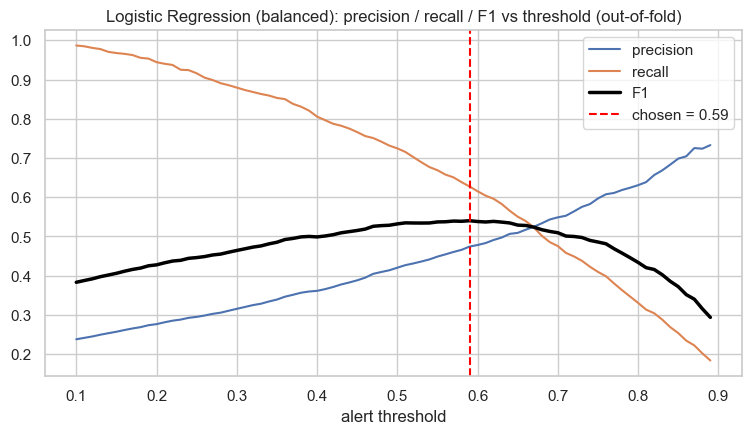

Chosen threshold = 0.59
OOF precision=0.474  recall=0.627  F1=0.540
Share of shipments flagged: 27.2%  ->  about 2,177 alerts/week at 8,000 shipments/week


In [ ]:
p_oof = oof[best_name]
thresholds = np.arange(0.10, 0.90, 0.01)
rows = []
for t in thresholds:
    pred = (p_oof >= t).astype(int)
    rows.append({"threshold": t, "precision": precision_score(y_train, pred, zero_division=0),
                 "recall": recall_score(y_train, pred), "f1": f1_score(y_train, pred),
                 "flagged_share": pred.mean()})
thr_df = pd.DataFrame(rows)
THRESHOLD = float(thr_df.loc[thr_df.f1.idxmax(), "threshold"])
THRESHOLD = round(THRESHOLD, 2)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(thr_df.threshold, thr_df.precision, label="precision")
ax.plot(thr_df.threshold, thr_df.recall, label="recall")
ax.plot(thr_df.threshold, thr_df.f1, label="F1", lw=2.5, color="black")
ax.axvline(THRESHOLD, color="red", ls="--", label=f"chosen = {THRESHOLD}")
ax.set_xlabel("alert threshold"); ax.set_title(f"{best_name}: precision / recall / F1 vs threshold (out-of-fold)")
ax.legend(); plt.show()

chosen = thr_df.loc[thr_df.threshold.round(2) == THRESHOLD].iloc[0]
print(f"Chosen threshold = {THRESHOLD}")
print(f"OOF precision={chosen.precision:.3f}  recall={chosen.recall:.3f}  F1={chosen.f1:.3f}")
print(f"Share of shipments flagged: {chosen.flagged_share:.1%}  ->  about {chosen.flagged_share * 8000:,.0f} alerts/week at 8,000 shipments/week")

### Final held-out test results: baseline vs final model

In [ ]:
final_pipe = models[best_name].fit(X_train, y_train)
base_pipe = models[BASELINE].fit(X_train, y_train)
dummy_pipe = models["Dummy (always on-time)"].fit(X_train, y_train)
bal_lr = models["Logistic Regression (balanced)"].fit(X_train, y_train)

proba = {
    "Dummy (always on-time)": dummy_pipe.predict_proba(X_test)[:, 1],
    "Logistic Regression (baseline)": base_pipe.predict_proba(X_test)[:, 1],
    f"{best_name} @ 0.50": final_pipe.predict_proba(X_test)[:, 1],
    f"{best_name} @ {THRESHOLD} (chosen)": final_pipe.predict_proba(X_test)[:, 1],
}
thr_map = {k: (THRESHOLD if "chosen" in k else 0.5) for k in proba}
test_table = pd.DataFrame([summarize(k, y_test, v, thr_map[k]) for k, v in proba.items()]).set_index("model").round(3)
display(test_table)

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,,
Dummy (always on-time),0.50,0.794,0.000,0.000,0.000,0.500,0.206
Logistic Regression (baseline),0.50,0.832,0.680,0.352,0.464,0.832,0.601
Logistic Regression (balanced) @ 0.50,0.50,0.754,0.442,0.741,0.554,0.832,0.603
Logistic Regression (balanced) @ 0.59 (chosen),0.59,0.794,0.500,0.664,0.570,0.832,0.603


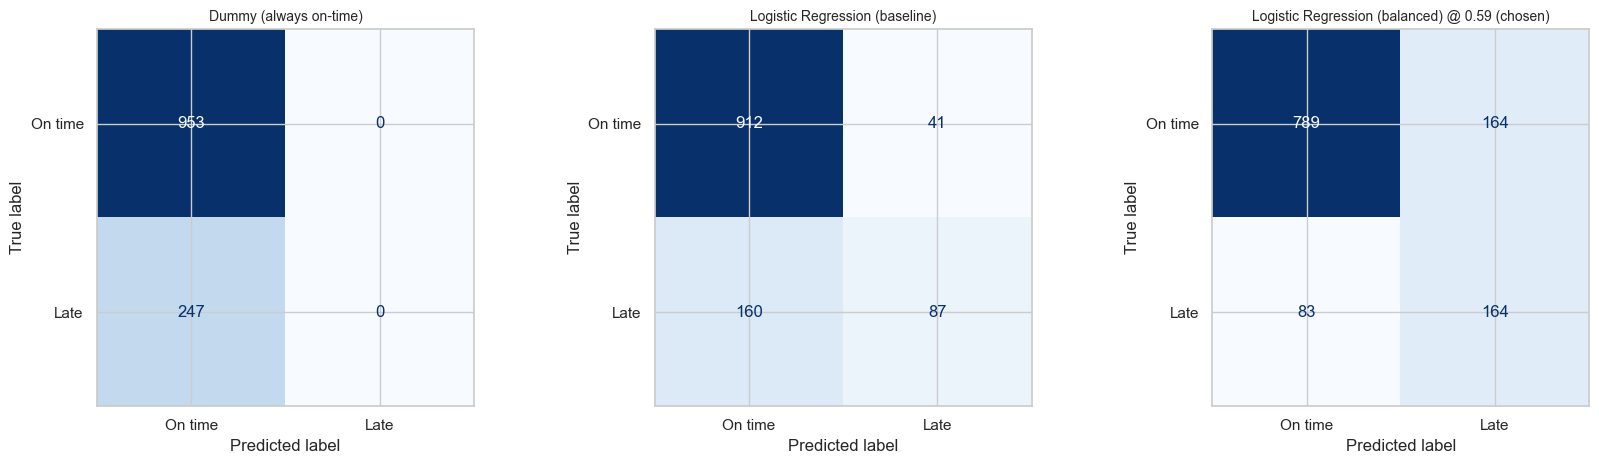

Final model on test: TP=164 (late caught)  FN=83 (late missed)  FP=164 (false alarms)  TN=789


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
panels = [("Dummy (always on-time)", 0.5), ("Logistic Regression (baseline)", 0.5), (f"{best_name} @ {THRESHOLD} (chosen)", THRESHOLD)]
for ax, (name, thr) in zip(axes, panels):
    pred = (proba[name] >= thr).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["On time", "Late"]).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=10)
plt.tight_layout(); plt.show()

final_pred = (proba[f"{best_name} @ {THRESHOLD} (chosen)"] >= THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, final_pred).ravel()
print(f"Final model on test: TP={tp} (late caught)  FN={fn} (late missed)  FP={fp} (false alarms)  TN={tn}")

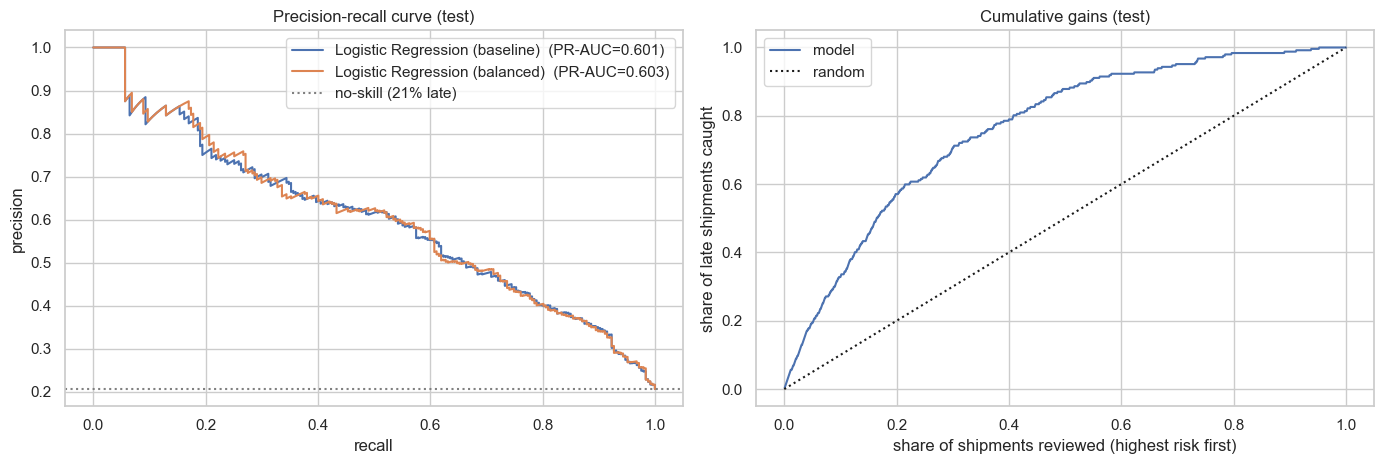

Reviewing the top 10% riskiest shipments catches 33% of late deliveries
Reviewing the top 20% riskiest shipments catches 57% of late deliveries
Reviewing the top 30% riskiest shipments catches 70% of late deliveries


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for name in ["Logistic Regression (baseline)", f"{best_name} @ 0.50"]:
    p, r, _ = precision_recall_curve(y_test, proba[name])
    axes[0].plot(r, p, label=f"{name.split(' @')[0]}  (PR-AUC={average_precision_score(y_test, proba[name]):.3f})")
axes[0].axhline(y_test.mean(), color="grey", ls=":", label="no-skill (21% late)")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision"); axes[0].set_title("Precision-recall curve (test)"); axes[0].legend()

pt = proba[f"{best_name} @ 0.50"]
order = np.argsort(-pt); k = np.arange(1, len(order) + 1)
gain = np.cumsum(y_test.values[order]) / y_test.sum()
axes[1].plot(k / len(k), gain, label="model"); axes[1].plot([0, 1], [0, 1], "k:", label="random")
axes[1].set_xlabel("share of shipments reviewed (highest risk first)"); axes[1].set_ylabel("share of late shipments caught")
axes[1].set_title("Cumulative gains (test)"); axes[1].legend(); plt.tight_layout(); plt.show()
for share in [0.1, 0.2, 0.3]:
    print(f"Reviewing the top {share:.0%} riskiest shipments catches {gain[int(share * len(k)) - 1]:.0%} of late deliveries")

## Model explainability
Which inputs push a shipment towards "late"? Permutation importance (drop in PR-AUC when a feature is shuffled, measured on the test set) works for any model, and the signs/direction come from the model coefficients / SHAP.

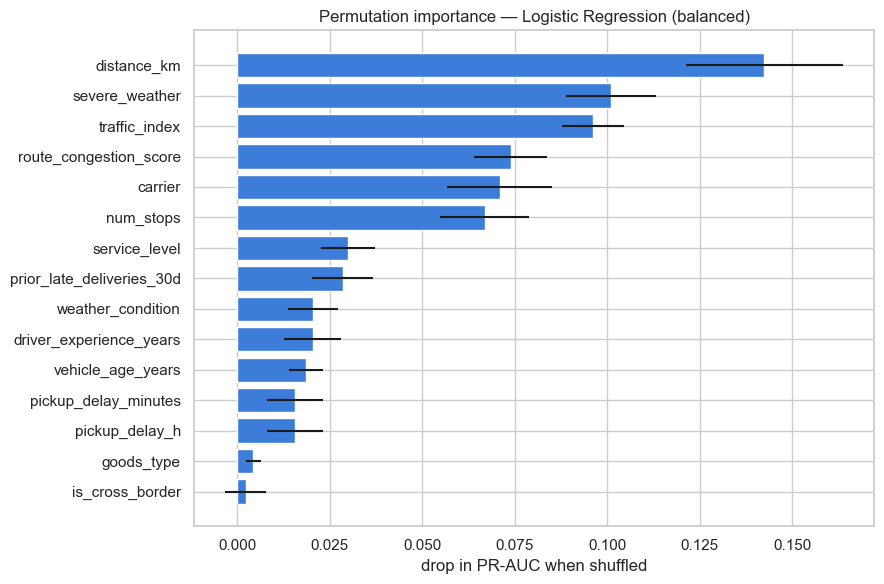

,importance
distance_km,0.1425
severe_weather,0.1009
traffic_index,0.0961
route_congestion_score,0.0739
carrier,0.0709
num_stops,0.0669
service_level,0.0299
prior_late_deliveries_30d,0.0285
weather_condition,0.0205
driver_experience_years,0.0203


In [ ]:
perm = permutation_importance(final_pipe, X_test, y_test, scoring="average_precision",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=1)
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
imp_std = pd.Series(perm.importances_std, index=X_test.columns).reindex(imp.index)
top = imp.head(15)[::-1]
plt.figure(figsize=(9, 6))
plt.barh(top.index, top.values, xerr=imp_std.reindex(top.index).values, color="#3b7dd8")
plt.xlabel("drop in PR-AUC when shuffled"); plt.title(f"Permutation importance — {best_name}")
plt.tight_layout(); plt.show()
display(imp.head(10).round(4).to_frame("importance"))

Background dataset has 4800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4800 when initializing the masker.


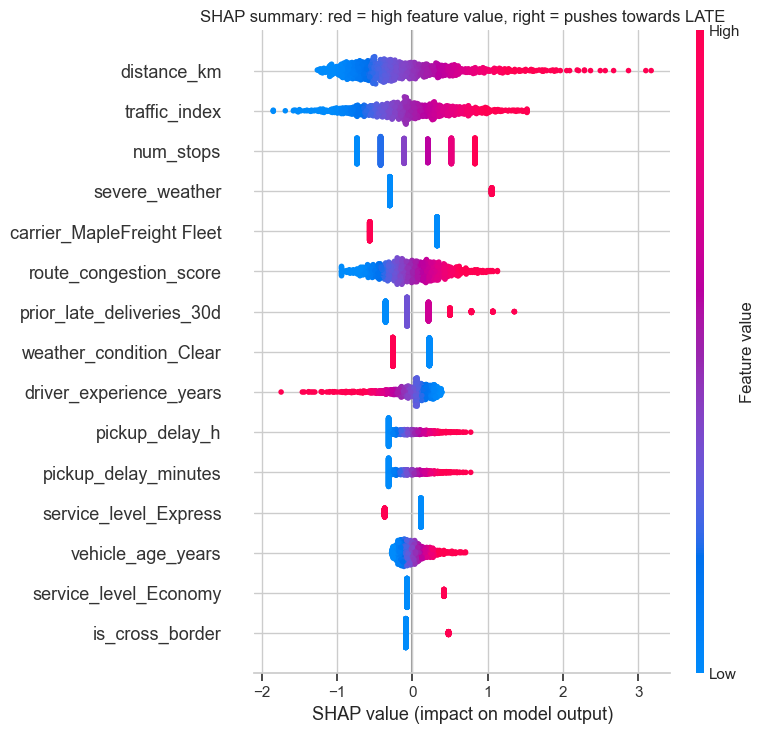

In [ ]:
import shap
pre_fit = final_pipe.named_steps["pre"]
Xt = pre_fit.transform(X_test)
Xt = Xt.toarray() if hasattr(Xt, "toarray") else Xt
feat_names = pre_fit.get_feature_names_out()
est = final_pipe.named_steps["m"]
if hasattr(est, "coef_"):
    explainer = shap.LinearExplainer(est, pre_fit.transform(X_train).toarray() if hasattr(pre_fit.transform(X_train), "toarray") else pre_fit.transform(X_train))
else:
    explainer = shap.TreeExplainer(est)
sv = explainer.shap_values(Xt)
sv = sv[1] if isinstance(sv, list) else sv
shap.summary_plot(sv, Xt, feature_names=[n.replace("num__", "").replace("cat__", "") for n in feat_names], max_display=15, show=False)
plt.title("SHAP summary: red = high feature value, right = pushes towards LATE")
plt.tight_layout(); plt.show()

## Slack alert integration

In [ ]:
load_dotenv()
SLACK_WEBHOOK_URL = os.environ.get("SLACK_WEBHOOK_URL")   # never print this value

scored = ids.loc[X_test.index].copy()
scored["risk_score"] = final_pipe.predict_proba(X_test)[:, 1]
at_risk = scored[scored.risk_score >= THRESHOLD].sort_values("risk_score", ascending=False)
print(f"{len(at_risk)} of {len(scored)} in-transit shipments are above the alert threshold ({THRESHOLD}).")
display(at_risk.head(5))

328 of 1200 in-transit shipments are above the alert threshold (0.59).


,shipment_id,origin_city,destination_city,carrier,risk_score
5295,SHP-100936,Toronto ON,Calgary AB,PrairieLine,0.987970
1557,SHP-103230,Montreal QC,Regina SK,Contract Owner-Op,0.981342
554,SHP-103300,Mississauga ON,Winnipeg MB,NorthStar Carriers,0.977444
2112,SHP-102910,Montreal QC,Edmonton AB,QuebecExpress,0.976589
3048,SHP-105511,Toronto ON,Ottawa ON,NorthStar Carriers,0.974338


In [ ]:
def build_slack_message(at_risk_df, total, threshold, top_n=5):
    lines = [f":rotating_light: *{len(at_risk_df)} of {total} in-transit shipments at risk of late delivery* (risk >= {threshold:.2f})",
             "Top by risk score:"]
    for _, r in at_risk_df.head(top_n).iterrows():
        lines.append(f"- *{r.shipment_id}* → {r.destination_city} | {r.carrier} | risk {r.risk_score:.0%}")
    lines.append("_Re-route or warn the customer now._")
    return "\n".join(lines)

def send_slack_alert(message, webhook_url):
    if not webhook_url:
        print("DRY RUN: no SLACK_WEBHOOK_URL found in .env, so nothing was sent. Message that would be posted:\n")
        print(message)
        return None
    resp = requests.post(webhook_url, json={"text": message}, timeout=10)
    print("Slack response:", resp.status_code, resp.text)   # 200 / "ok" means delivered
    return resp.status_code

message = build_slack_message(at_risk, len(scored), THRESHOLD)
if len(at_risk) > 0:
    status = send_slack_alert(message, SLACK_WEBHOOK_URL)
else:
    print("No high-risk shipments: nothing to send.")

Slack response: 404 no_team
